In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from pystout import pystout

from main_results import *


In [3]:


def set_plot_theme():
    # base seaborn theme & palette
    sns.set_theme(
        style="white",           # consistent with file_context_0
        palette=["#3c5488", "#e64b35", "#4dbbd5", "#00a087", "#f39b7f"],          # or your own list of colors
        font="serif",            # consistent with file_context_0
        font_scale=1.1
    )

    # tweak matplotlib rcParams you care about
    plt.rcParams.update({
        "text.usetex":       True,  # consistent with file_context_0
        "axes.titlesize":    16,
        "axes.labelsize":    14,
        "legend.frameon":    False,
        "figure.figsize":    (8, 5),
        "lines.linewidth":   2,
        "lines.markersize":  6,
        # …any other defaults…
    })

def finalize_plot(ax=None):
    if ax is None:
        ax = plt.gca()
    sns.despine(ax=ax)
    ax.figure.tight_layout()

In [4]:
df = pd.read_csv("/Users/nicolasroever/Dropbox/Promotion/Bargaining/bargaining_experiment_analysis/bld/data/merged_data_full_excluded.csv")

In [5]:
print(len(df))
set_plot_theme()

3472


In [6]:
df_asymmetric = df[df['information_asymmetry'] == 'Asymmetric']

## Check MAin Behavcioral Hypotheses

In [7]:
import statsmodels.formula.api as smf
import pandas as pd

behavioral = smf.ols(formula='payoff ~ C(participant_role) + C(information_asymmetry) + C(TA_costs) + C(TA_costs) * C(information_asymmetry) + ultimatum_indicator + risk_elicitation_choice + time_preference_switching_points + first_offer + valuation', data=df).fit()

print(behavioral.summary())

                            OLS Regression Results                            
Dep. Variable:                 payoff   R-squared:                       0.040
Model:                            OLS   Adj. R-squared:                  0.037
Method:                 Least Squares   F-statistic:                     14.46
Date:                Wed, 18 Jun 2025   Prob (F-statistic):           3.60e-23
Time:                        08:45:19   Log-Likelihood:                -10851.
No. Observations:                3134   AIC:                         2.172e+04
Df Residuals:                    3124   BIC:                         2.178e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                                                coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------

In [8]:
efficiency = smf.ols(formula='efficiency ~ C(information_asymmetry) + C(TA_costs) + C(TA_costs) * C(information_asymmetry) + ultimatum_indicator + risk_elicitation_choice + time_preference_switching_points + first_offer + valuation', data=df).fit()

print(efficiency.summary())

                            OLS Regression Results                            
Dep. Variable:             efficiency   R-squared:                       0.066
Model:                            OLS   Adj. R-squared:                  0.064
Method:                 Least Squares   F-statistic:                     27.80
Date:                Wed, 18 Jun 2025   Prob (F-statistic):           4.22e-42
Time:                        08:45:19   Log-Likelihood:                -1912.1
No. Observations:                3134   AIC:                             3842.
Df Residuals:                    3125   BIC:                             3897.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                                                                coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------

## Now, I check one sided uncertainty

In [9]:
df_one_sided = df[(df["treatment"] == "T3") | (df["treatment"] == "T4")]

Percentage below 0: 1.56%
Percentage above 1: 1.56%


<Axes: >

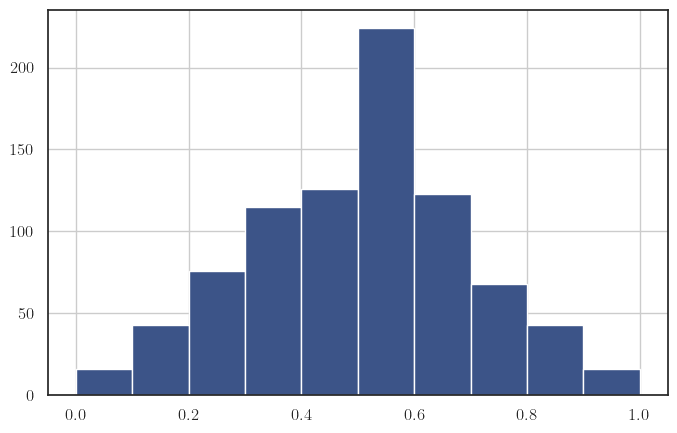

In [12]:
below_zero = (df_one_sided["split_gains_from_trade"] < 0).mean() * 100
above_one = (df_one_sided["split_gains_from_trade"] > 1).mean() * 100

print(f"Percentage below 0: {below_zero:.2f}%")
print(f"Percentage above 1: {above_one:.2f}%")

df_one_sided["split_gains_from_trade"].hist(range=(0, 1))

In [15]:
first_offer = smf.ols(formula='first_offer ~ C(participant_role)', data=df_one_sided).fit()

print(first_offer.summary())

                            OLS Regression Results                            
Dep. Variable:            first_offer   R-squared:                       0.023
Model:                            OLS   Adj. R-squared:                  0.022
Method:                 Least Squares   F-statistic:                     37.07
Date:                Wed, 18 Jun 2025   Prob (F-statistic):           1.42e-09
Time:                        08:48:37   Log-Likelihood:                -1134.2
No. Observations:                1588   AIC:                             2272.
Df Residuals:                    1586   BIC:                             2283.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept     

In [26]:
split_gains = smf.ols(formula='split_gains_from_trade ~ C(participant_role) + C(TA_costs)', data=df_one_sided).fit()

print(split_gains.summary())

                              OLS Regression Results                              
Dep. Variable:     split_gains_from_trade   R-squared:                       0.016
Model:                                OLS   Adj. R-squared:                  0.014
Method:                     Least Squares   F-statistic:                     7.512
Date:                    Wed, 18 Jun 2025   Prob (F-statistic):           0.000582
Time:                            08:56:13   Log-Likelihood:                -1323.9
No. Observations:                     904   AIC:                             2654.
Df Residuals:                         901   BIC:                             2668.
Df Model:                               2                                         
Covariance Type:                nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------

In [30]:
payoff = smf.ols(formula='payoff ~ C(participant_role) + C(TA_costs)', data=df_one_sided).fit()

print(payoff.summary())

                            OLS Regression Results                            
Dep. Variable:                 payoff   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     1.281
Date:                Wed, 18 Jun 2025   Prob (F-statistic):              0.278
Time:                        08:57:25   Log-Likelihood:                -5758.9
No. Observations:                1736   AIC:                         1.152e+04
Df Residuals:                    1733   BIC:                         1.154e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept     

In [31]:
efficiency = smf.ols(formula='efficiency ~  C(TA_costs) + gains_from_trade', data=df_one_sided).fit()

print(efficiency.summary())

                            OLS Regression Results                            
Dep. Variable:             efficiency   R-squared:                       0.185
Model:                            OLS   Adj. R-squared:                  0.184
Method:                 Least Squares   F-statistic:                     197.1
Date:                Wed, 18 Jun 2025   Prob (F-statistic):           7.33e-78
Time:                        09:03:47   Log-Likelihood:                -1075.4
No. Observations:                1736   AIC:                             2157.
Df Residuals:                    1733   BIC:                             2173.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               0.1827    

In [19]:
agreement = smf.ols(formula='agreement_dummy ~ C(TA_costs)', data=df_one_sided).fit()

print(agreement.summary())

                            OLS Regression Results                            
Dep. Variable:        agreement_dummy   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.3319
Date:                Wed, 18 Jun 2025   Prob (F-statistic):              0.565
Time:                        08:50:18   Log-Likelihood:                -1258.6
No. Observations:                1736   AIC:                             2521.
Df Residuals:                    1734   BIC:                             2532.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               0.5253    

In [23]:
bargaining_duration = smf.ols(formula='bargaining_time_full_sec ~ C(TA_costs)', data=df_one_sided).fit()

print(bargaining_duration.summary())

                               OLS Regression Results                               
Dep. Variable:     bargaining_time_full_sec   R-squared:                       0.001
Model:                                  OLS   Adj. R-squared:                  0.000
Method:                       Least Squares   F-statistic:                     1.316
Date:                      Wed, 18 Jun 2025   Prob (F-statistic):              0.251
Time:                              08:51:22   Log-Likelihood:                -7550.8
No. Observations:                      1736   AIC:                         1.511e+04
Df Residuals:                          1734   BIC:                         1.512e+04
Df Model:                                 1                                         
Covariance Type:                  nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------

In [25]:
pystout(models=[first_offer, split_gains, efficiency, agreement],
    file='sandbox.tex',
    addnotes=['\\textit{Notes:} These regressions are run on the data from the treatments with asymmetric uncertainty. Dummy First Offer is indicator equal to 1 if the player has made the first offer, split gains from trade is percentage of the surplus the player extracts from a successfull trade (we exclude transaction costs for this measure), efficiency is indicator equal to 1 if an agreement was reached and 0 otherwise (surplus is always at leas zero in the considered treatmends) and Dummy Agreement is an indicator equal to 1 if an agreement was reached.'],
    digits=2,
    endog_names=['Dummy First Offer', "Split Gains from Trade", "Efficiency", "Dummy Agreement"],
    varlabels={'const':'Constant','first_offer':'First Offer', 'split_gains_from_trade':'Split Gains from Trade', 'efficiency':'Efficiency', 'agreement_dummy':'Dummy Agreement', 'C(participant_role)[T.Seller]':'Seller', 'C(TA_costs)[T.0.05]':'TA Costs $= 0.05$', 'gains_from_trade':'Gains from Trade'},
    modstat={'nobs':'Obs','rsquared_adj':'Adj. R\sym{2}'}
    )

<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\s'
/var/folders/f_/lhmm20kd6r979skh60tngks80000gn/T/ipykernel_88673/80041063.py:7: SyntaxWarning: invalid escape sequence '\s'
  modstat={'nobs':'Obs','rsquared_adj':'Adj. R\sym{2}'}


## I would like to look at two sided uncertainty. 
- first mover advantage?
- Longer silence signals lower valuation
- Adding transaction costs

In [31]:
df_twosided = df[(df["treatment"] == "T2")]

In [32]:
df_regression = df.dropna(subset=["first_offer"])

first_mover_advantage = smf.ols(formula='split_gains_from_trade ~ first_offer', data=df_twosided).fit()

# 4. Examine the results
print(first_mover_advantage.summary())

                              OLS Regression Results                              
Dep. Variable:     split_gains_from_trade   R-squared:                       0.019
Model:                                OLS   Adj. R-squared:                  0.015
Method:                     Least Squares   F-statistic:                     4.831
Date:                    Mon, 16 Jun 2025   Prob (F-statistic):             0.0289
Time:                            14:17:01   Log-Likelihood:                -739.97
No. Observations:                     248   AIC:                             1484.
Df Residuals:                         246   BIC:                             1491.
Df Model:                               1                                         
Covariance Type:                nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept 

<Axes: >

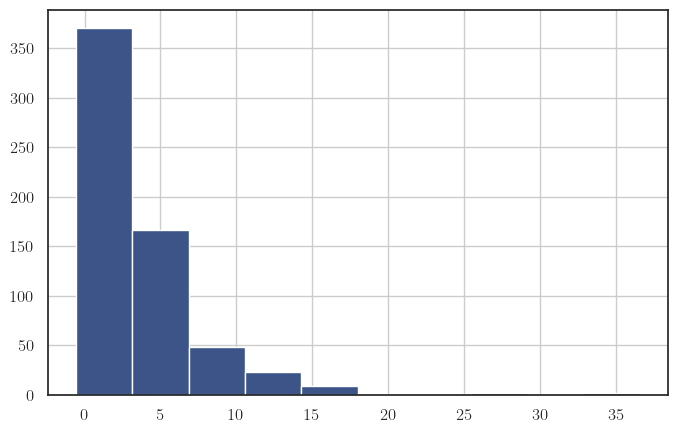

In [33]:
df_twosided["offer_time_1"].hist()

In [34]:
slient_signaling = smf.ols(formula='valuation ~ offer_time_1', data=df_twosided).fit()

print(slient_signaling.summary())

                            OLS Regression Results                            
Dep. Variable:              valuation   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.002
Method:                 Least Squares   F-statistic:                   0.02709
Date:                Mon, 16 Jun 2025   Prob (F-statistic):              0.869
Time:                        14:17:01   Log-Likelihood:                -2627.3
No. Observations:                 622   AIC:                             5259.
Df Residuals:                     620   BIC:                             5268.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       27.3726      0.913     29.965   

In [35]:

pystout(models=[first_mover_advantage, slient_signaling],
file='regression.tex',
addnotes=['Here is a little note','And another one'],
digits=2,
endog_names=['Split Gains from Trade', "Valuation"],
varlabels={'const':'Constant','first_offer':'First Offer', 'offer_time_1':'First Offer Time'},
modstat={'nobs':'Obs','rsquared_adj':'Adj. R\sym{2}'}
)

<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\s'
/var/folders/f_/lhmm20kd6r979skh60tngks80000gn/T/ipykernel_69089/17651594.py:7: SyntaxWarning: invalid escape sequence '\s'
  modstat={'nobs':'Obs','rsquared_adj':'Adj. R\sym{2}'}


## Time Preferences

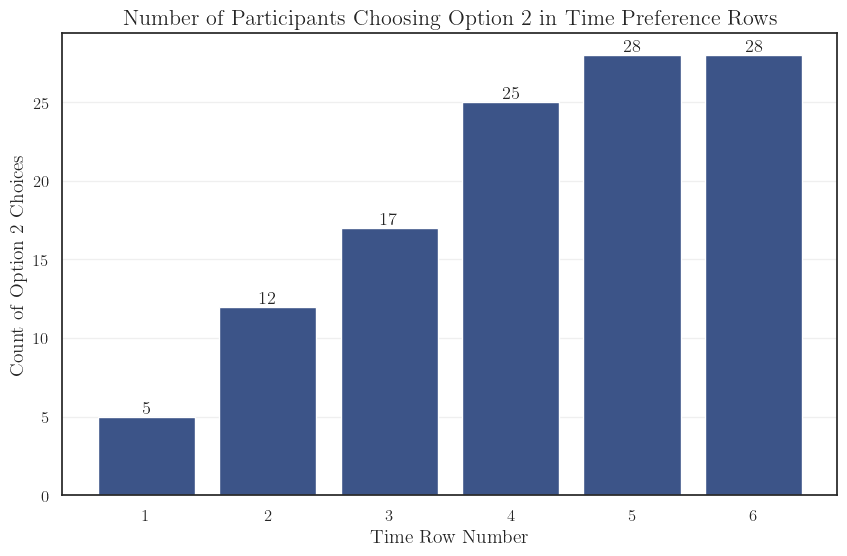

In [5]:
df_round33 = df[df['round'] == 33]

# Calculate counts of value 2 for each time_row column
counts = []
for i in range(1, 7):
    col = f'time_row_{i}'
    count = (df_round33[col] == 2).sum()
    counts.append(count)

# Create the plot
plt.figure(figsize=(10, 6))
bars = plt.bar(range(1, 7), counts)

# Add value labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}',
            ha='center', va='bottom')

# Customize the plot
plt.title('Number of Participants Choosing Option 2 in Time Preference Rows')
plt.xlabel('Time Row Number')
plt.ylabel('Count of Option 2 Choices')
plt.xticks(range(1, 7))
plt.grid(axis='y', alpha=0.3)

# Show the plot
plt.show()

In [23]:
# Initialize list to store violations
violations = []

# Check each participant's choices
for _, row in df_round33.iterrows():
    choices = [row[f'time_row_{i}'] for i in range(1, 7)]
    switched_to_2 = False
    violation = False
    
    for i, choice in enumerate(choices):
        if choice == 2:
            switched_to_2 = True
        elif choice == 1 and switched_to_2:
            violation = True
            violations.append({
                'participant_id': row['participant_id'],
                'violation_at_row': i + 1,
                'choices': choices
            })
            break

# Create DataFrame of violations
violations_df = pd.DataFrame(violations)

In [24]:
violations_df

""


## Main Plot

<module 'matplotlib.pyplot' from '/Users/nicolasroever/opt/anaconda3/envs/bargaining_analysis/lib/python3.12/site-packages/matplotlib/pyplot.py'>

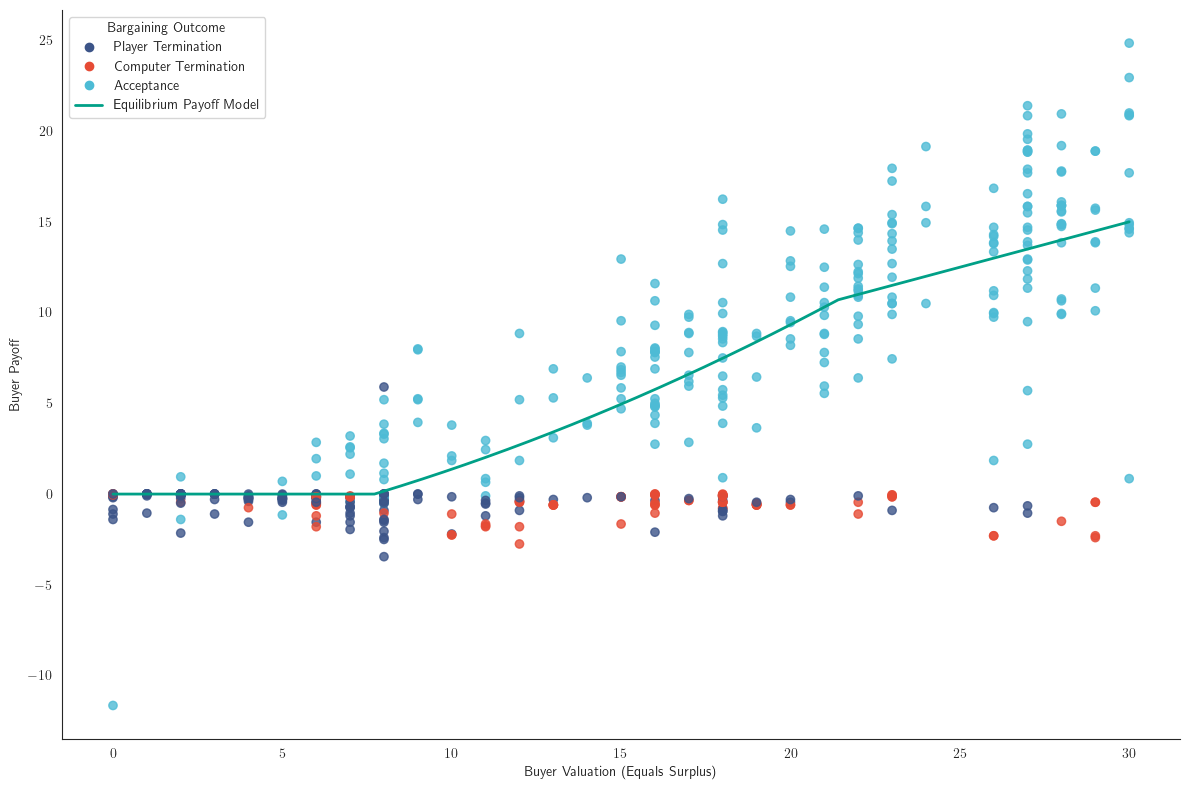

In [13]:
plot_T4_buyer_payoff_vs_valuation(df, COLOR_SCHEME)

## First Mover Seller Predictions

In [14]:
df_regression = df.dropna(subset=["first_offer"])


model_1 = smf.ols(formula='first_offer ~ C(participant_role)', data=df_regression).fit()

# 4. Examine the results
print(model_1.summary())

                            OLS Regression Results                            
Dep. Variable:            first_offer   R-squared:                       0.010
Model:                            OLS   Adj. R-squared:                  0.009
Method:                 Least Squares   F-statistic:                     8.813
Date:                Wed, 11 Jun 2025   Prob (F-statistic):            0.00308
Time:                        16:25:37   Log-Likelihood:                -609.63
No. Observations:                 846   AIC:                             1223.
Df Residuals:                     844   BIC:                             1233.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept     

In [15]:
df["efficiency"].mean()

np.float64(0.5031315240083507)

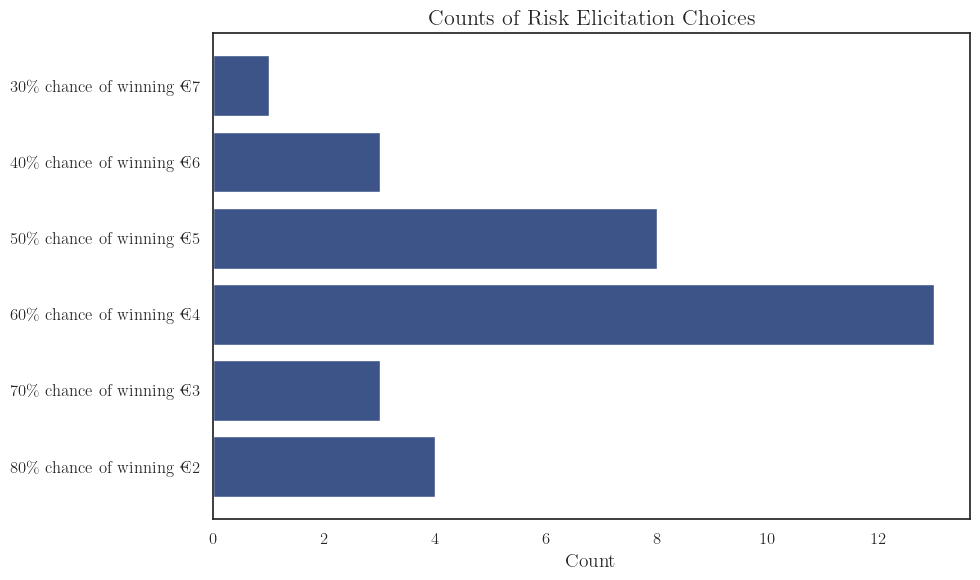

In [12]:
# (re)compute your counts
risk_labels = [
    r"80\% chance of winning €2",
    r"70\% chance of winning €3",
    r"60\% chance of winning €4",
    r"50\% chance of winning €5",
    r"40\% chance of winning €6",
    r"30\% chance of winning €7"
]
risk_counts = df_round33["risk_elicitation_choice"] \
    .value_counts() \
    .reindex(range(1, 7), fill_value=0)

# horizontal bar plot
plt.figure(figsize=(10, 6))
plt.barh(risk_labels, risk_counts.values)
plt.xlabel('Count')
plt.title('Counts of Risk Elicitation Choices')
plt.tight_layout()
plt.show()

<Axes: >

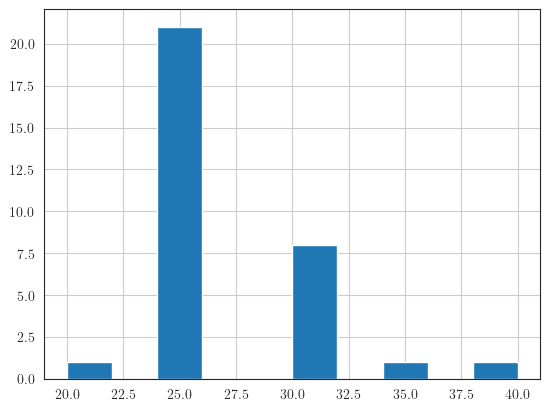

In [16]:
def plot_ultimatum_offer_histogram(df):
    """
    Plots a histogram of ultimatum offers for round 33.

    Parameters:
    df (pd.DataFrame): The DataFrame containing the data.

    Returns:
    None
    """
    df[df["round"] == 33]["ultimatum_offer"].hist()
    plt.xlabel('Money to Keep in Euros')
    plt.ylabel('Frequency')
    plt.title('Histogram of Ultimatum Offers in Round 33')
    plt.show()

# Example usage:
# plot_ultimatum_offer_histogram(df)

<Axes: >

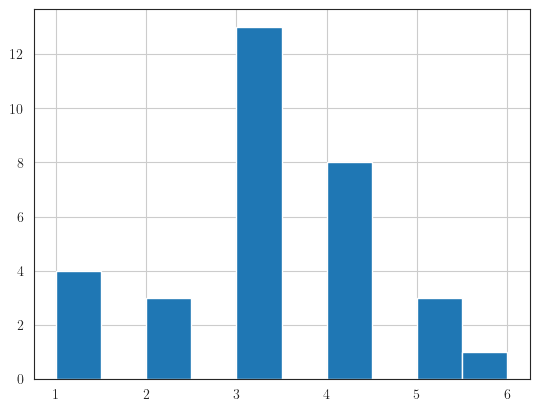

In [17]:
df[df["round"] == 33]["risk_elicitation_choice"].hist()

In [8]:
df_regression = df.dropna(subset=["efficiency"])


model_1 = smf.ols(formula='efficiency ~ ultimatum_indicator', data=df_regression).fit()

# 4. Examine the results
print(model_1.summary())

                            OLS Regression Results                            
Dep. Variable:             efficiency   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     1.593
Date:                Wed, 11 Jun 2025   Prob (F-statistic):              0.207
Time:                        16:22:48   Log-Likelihood:                -694.49
No. Observations:                 958   AIC:                             1393.
Df Residuals:                     956   BIC:                             1403.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               0.5333    

In [18]:
df_regression = df.dropna(subset=["efficiency"])


model_1 = smf.ols(formula='efficiency ~ risk_elicitation_choice', data=df_regression).fit()

# 4. Examine the results
print(model_1.summary())

                            OLS Regression Results                            
Dep. Variable:             efficiency   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.5225
Date:                Wed, 11 Jun 2025   Prob (F-statistic):              0.470
Time:                        16:25:57   Log-Likelihood:                -695.03
No. Observations:                 958   AIC:                             1394.
Df Residuals:                     956   BIC:                             1404.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

# Old Stuff

In [5]:
df = pd.read_csv("/Users/nicolasroever/Dropbox/Promotion/Bargaining/bargaining_experiment_analysis/src/bargaining_analysis/data/DataCollection130052025/all_apps_wide-2025-05-14.csv")



In [6]:
df_two_sided = pd.read_pickle("/Users/nicolasroever/Dropbox/Promotion/Bargaining/bargaining_experiment_analysis/bld/data/two_sided_without_TA.pkl")

## First Mover Regression

<Axes: >

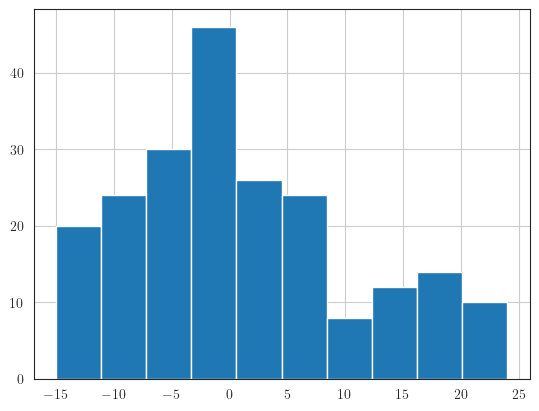

In [7]:
df_two_sided["gains_from_trade"].hist()

In [8]:
df_regression = df_two_sided.dropna(subset=["payoff", "first_offer"])

df_regression["payoff"] = pd.to_numeric(df_regression["payoff"], errors='coerce') 

model_1 = smf.ols(formula='payoff ~ first_offer', data=df_regression).fit()

# 4. Examine the results
print(model_1.summary())

                            OLS Regression Results                            
Dep. Variable:                 payoff   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.005
Method:                 Least Squares   F-statistic:                 0.0002500
Date:                Wed, 11 Jun 2025   Prob (F-statistic):              0.987
Time:                        15:31:55   Log-Likelihood:                -553.18
No. Observations:                 188   AIC:                             1110.
Df Residuals:                     186   BIC:                             1117.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       2.1277      0.476      4.472      

/var/folders/f_/lhmm20kd6r979skh60tngks80000gn/T/ipykernel_10250/536089823.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_regression["payoff"] = pd.to_numeric(df_regression["payoff"], errors='coerce')


In [9]:
df_regression = df_two_sided[df_two_sided["split_gains_from_trade"] > 0]

df_regression["payoff"] = pd.to_numeric(df_regression["payoff"], errors='coerce') 

df_regression.dropna(subset=["split_gains_from_trade", "first_offer"], inplace=True)

model_2 = smf.ols(formula='split_gains_from_trade ~ first_offer', data=df_regression).fit()

# 4. Examine the results
print(model_2.summary())

                              OLS Regression Results                              
Dep. Variable:     split_gains_from_trade   R-squared:                       0.047
Model:                                OLS   Adj. R-squared:                  0.030
Method:                     Least Squares   F-statistic:                     2.781
Date:                    Wed, 11 Jun 2025   Prob (F-statistic):              0.101
Time:                            15:31:55   Log-Likelihood:                -59.368
No. Observations:                      59   AIC:                             122.7
Df Residuals:                          57   BIC:                             126.9
Df Model:                               1                                         
Covariance Type:                nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept 

/var/folders/f_/lhmm20kd6r979skh60tngks80000gn/T/ipykernel_10250/3190619071.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_regression["payoff"] = pd.to_numeric(df_regression["payoff"], errors='coerce')
/var/folders/f_/lhmm20kd6r979skh60tngks80000gn/T/ipykernel_10250/3190619071.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_regression.dropna(subset=["split_gains_from_trade", "first_offer"], inplace=True)


In [10]:

model_3 = smf.ols(formula='bargaining_time_full_sec ~ valuation', data=df_two_sided).fit()

print(model_3.summary())

                               OLS Regression Results                               
Dep. Variable:     bargaining_time_full_sec   R-squared:                       0.007
Model:                                  OLS   Adj. R-squared:                  0.003
Method:                       Least Squares   F-statistic:                     1.598
Date:                      Wed, 11 Jun 2025   Prob (F-statistic):              0.208
Time:                              15:31:55   Log-Likelihood:                -4685.6
No. Observations:                       214   AIC:                             9375.
Df Residuals:                           212   BIC:                             9382.
Df Model:                                 1                                         
Covariance Type:                  nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------

In [11]:
pystout(models=[model_1, model_2],
        file='test_table.tex',
        addnotes=['Here is a little note','And another one'],
        digits=2,
        endog_names=['Payoff','Split Gains from Trade'],
        varlabels={'const':'Constant','first_offer':'First Offer'},
        modstat={'nobs':'Obs','rsquared_adj':'Adj. R\sym{2}'}
        )


<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\s'
/var/folders/f_/lhmm20kd6r979skh60tngks80000gn/T/ipykernel_10250/4137003316.py:7: SyntaxWarning: invalid escape sequence '\s'
  modstat={'nobs':'Obs','rsquared_adj':'Adj. R\sym{2}'}


In [12]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='valuation', y='gains_from_trade', data=df_buyers, alpha=0.7)

# Customize the plot
plt.title('Scatterplot of Valuation vs. Gains from Trade')
plt.xlabel('Valuation')
plt.ylabel('Gains from Trade')

# Show the plot
plt.show()


NameError: name 'df_buyers' is not defined

<Figure size 1000x600 with 0 Axes>

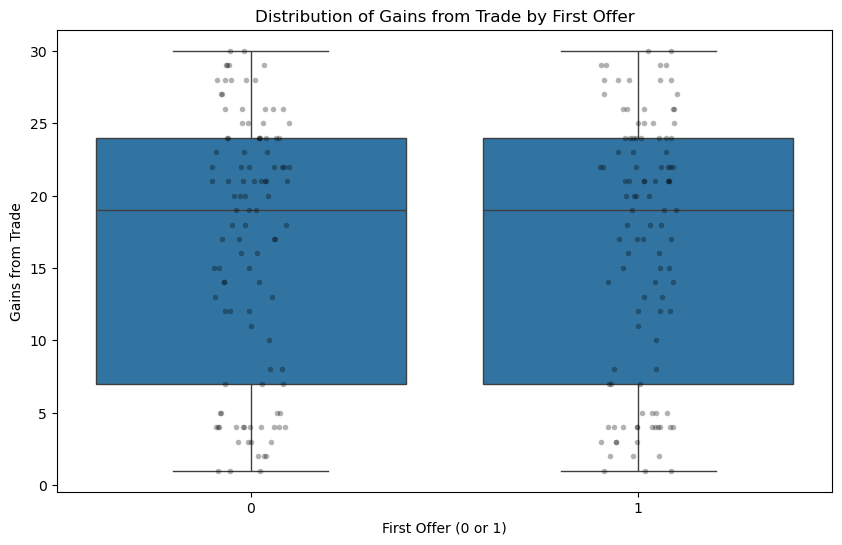

In [ ]:

plt.figure(figsize=(10, 6))
sns.boxplot(x='first_offer', y='gains_from_trade', data=df)

# Customize the plot
plt.title('Distribution of Gains from Trade by First Offer')
plt.xlabel('First Offer (0 or 1)')
plt.ylabel('Gains from Trade')

# Add individual data points
sns.stripplot(x='first_offer', y='gains_from_trade', data=df, 
              color='black', alpha=0.3, size=4)

# Save the plot
plt.show()

In [ ]:
df = pd.read_pickle("/Users/nicolasroever/Dropbox/Promotion/Bargaining/bargaining_experiment_analysis/bld/data/one_sided_with_TA.pkl")
df_buyers = df[(df["participant_role"] == "Buyer")]

In [3]:
# Define the piecewise function
def equilibrium_payoff(x, c=0.05, r=0.01):
    if x <= 7.72:
        return 0
    elif x >= 21.40:
        return x/2
    else:
        b = x
        return ((r*b + 2*c)/(r*21.40 + 2*c)) * (b/2 + c/r) - c/r


In [4]:
# Generate x values for the theoretical line
x_values = np.linspace(0, 30, 1000)
y_values = [equilibrium_payoff(x) for x in x_values]


COLOR_SCHEME=["#3c5488","#00a087", "#e64b35", "#4dbbd5",  "#f39b7f", ]
plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"
sns.set_style("white")
sns.set_palette(COLOR_SCHEME)


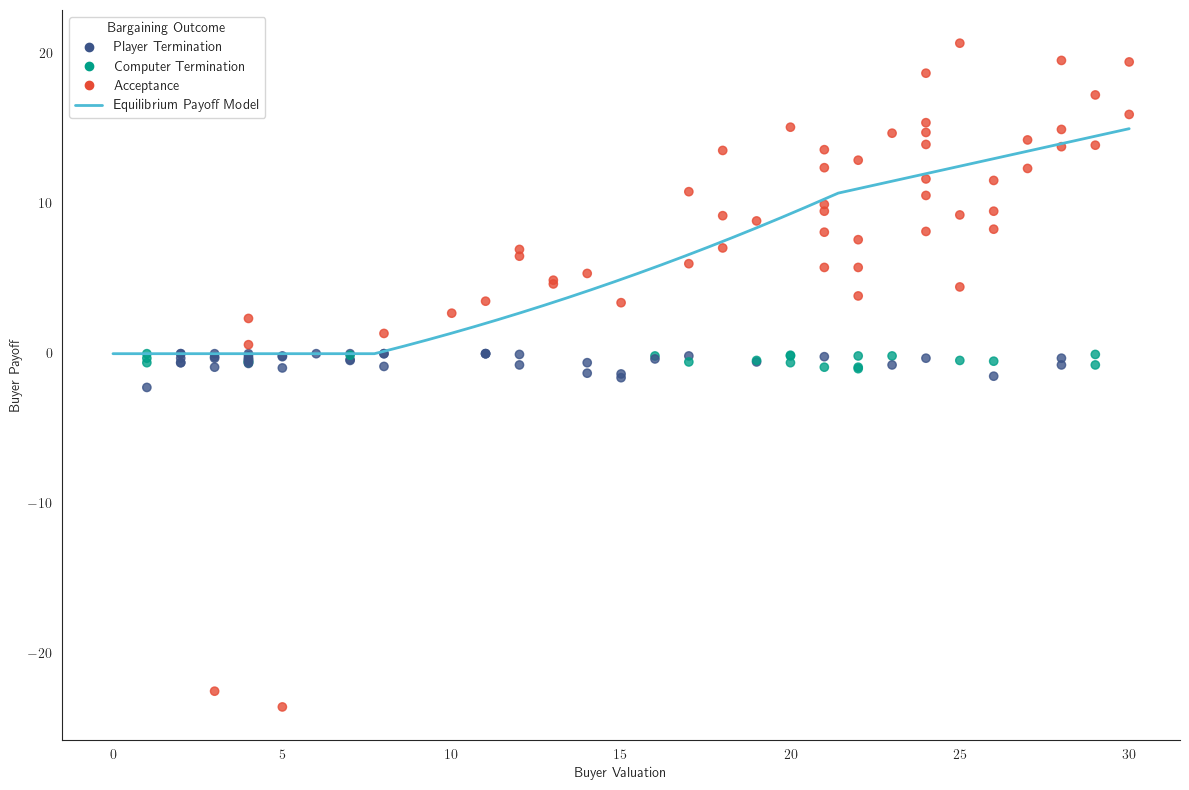

In [9]:

# Define your color scheme
COLOR_SCHEME = ["#3c5488", "#00a087", "#e64b35", "#4dbbd5", "#f39b7f"]

# Define a mapping from outcome labels to colors
outcome_color_map = {
    'Player': COLOR_SCHEME[0],               # Player Termination
    'Random_Termination': COLOR_SCHEME[1],   # Computer Termination
    'acceptance': COLOR_SCHEME[2],           # Highlight Acceptance
}

# Assign color values based on the outcome
colors = df_buyers['bargaining_outcome'].map(outcome_color_map)

plt.figure(figsize=(12, 8))

# Plot the theoretical line
plt.plot(x_values, y_values, color=COLOR_SCHEME[3], linewidth=2, label='Equilibrium Payoff Model')

# Add the scatter plot with custom colors
scatter = plt.scatter(
    df_buyers['valuation'],
    df_buyers['payoff'],
    c=colors,
    alpha=0.8
)

plt.xlabel('Buyer Valuation (Equals Surplus) ')
plt.ylabel('Buyer Payoff')

# Create custom legend
import matplotlib.lines as mlines
legend_elements = [
    mlines.Line2D([], [], color=COLOR_SCHEME[0], marker='o', linestyle='None', label='Player Termination'),
    mlines.Line2D([], [], color=COLOR_SCHEME[1], marker='o', linestyle='None', label='Computer Termination'),
    mlines.Line2D([], [], color=COLOR_SCHEME[2], marker='o', linestyle='None', label='Acceptance'),
    mlines.Line2D([], [], color=COLOR_SCHEME[3], linewidth=2, label='Equilibrium Payoff Model')
]

plt.legend(handles=legend_elements, title="Bargaining Outcome")

sns.despine()
plt.tight_layout()
plt.show()
